# Projectile Motion with Linear Drag

We simulate a ball of mass $m$ launched from the surface of the Earth with initial speed $v_i$ at angle $\theta$ above the horizontal.

## Forces
- **Gravity:** $\vec{F}_g = -mg\,\hat{y}$
- **Linear Drag:** $\vec{F}_d = -\alpha\,\vec{v}$

## Equations of Motion

$$m\frac{dv_x}{dt} = -\alpha\, v_x$$

$$m\frac{dv_y}{dt} = -mg - \alpha\, v_y$$

We solve these numerically using `scipy.integrate.solve_ivp`.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Parameters

In [47]:
# Physical parameters
m = 0.145          # mass of ball (kg)  [baseball]
g = 9.81           # gravitational acceleration (m/s^2)
alpha = 0.05       # linear drag coefficient (kg/s)

# Launch parameters
vi = 30.0                        # initial speed (m/s)
theta_deg = 45.0                 # launch angle (degrees)
theta = np.radians(theta_deg)    # convert to radians

# Initial conditions
x0, y0 = 0.0, 0.0
vx0 = vi * np.cos(theta)
vy0 = vi * np.sin(theta)

print(f"Mass:              m = {m} kg")
print(f"Drag coefficient:  α = {alpha} kg/s")
print(f"Initial speed:     vi = {vi} m/s")
print(f"Launch angle:      θ  = {theta_deg}°")
print(f"vx0 = {vx0:.3f} m/s,  vy0 = {vy0:.3f} m/s")

Mass:              m = 0.145 kg
Drag coefficient:  α = 0.05 kg/s
Initial speed:     vi = 30.0 m/s
Launch angle:      θ  = 45.0°
vx0 = 21.213 m/s,  vy0 = 21.213 m/s


## Define the ODE System

State vector: $\vec{s} = [x,\; y,\; v_x,\; v_y]$

$$\frac{d\vec{s}}{dt} = \begin{bmatrix} v_x \\ v_y \\ -\frac{\alpha}{m}\,v_x \\ -g - \frac{\alpha}{m}\,v_y \end{bmatrix}$$

In [48]:
def projectile_drag(t, s, m, g, alpha):
    """ODE system for projectile motion with linear drag."""
    x, y, vx, vy = s
    dxdt = vx
    dydt = vy
    dvxdt = -(alpha / m) * vx
    dvydt = -g - (alpha / m) * vy
    return [dxdt, dydt, dvxdt, dvydt]


def projectile_no_drag(t, s, m, g):
    """ODE system for projectile motion WITHOUT drag (for comparison)."""
    x, y, vx, vy = s
    return [vx, vy, 0.0, -g]

## Simulation Without Drag

Solve and plot the trajectory with **no drag** ($\alpha = 0$) for reference.

Without drag →  Range = 91.69 m,  Flight time = 4.32 s


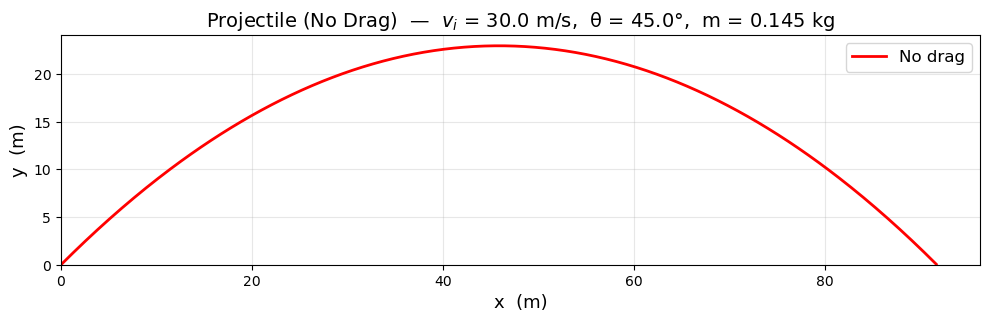

In [49]:
# Event: ball hits the ground (y = 0) after launch
def hit_ground(t, s, *args):
    return s[1]  # y coordinate

hit_ground.terminal = True
hit_ground.direction = -1  # trigger only when y is decreasing

# Time span and initial conditions
t_span = (0, 20)
t_eval = np.linspace(0, 20, 2000)
s0 = [x0, y0, vx0, vy0]

# ---------- Solve without drag ----------
sol_nodrag = solve_ivp(
    projectile_no_drag, t_span, s0,
    args=(m, g),
    events=hit_ground,
    t_eval=t_eval,
    dense_output=True,
    max_step=0.01
)

x_nd, y_nd = sol_nodrag.y[0], sol_nodrag.y[1]
t_nd = sol_nodrag.t

print(f"Without drag →  Range = {x_nd[-1]:.2f} m,  Flight time = {t_nd[-1]:.2f} s")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_nd, y_nd, 'r-', linewidth=2, label='No drag')

ax.set_xlabel('x  (m)', fontsize=13)
ax.set_ylabel('y  (m)', fontsize=13)
ax.set_title(f'Projectile (No Drag)  —  $v_i$ = {vi} m/s,  θ = {theta_deg}°,  m = {m} kg', fontsize=14)
ax.legend(fontsize=12)
ax.set_ylim(bottom=0)
ax.set_xlim(left=0)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Simulation With Drag

Now include the linear drag force $\vec{F}_d = -\alpha\,\vec{v}$ and compare.

With drag    →  Range = 43.69 m,  Flight time = 3.59 s


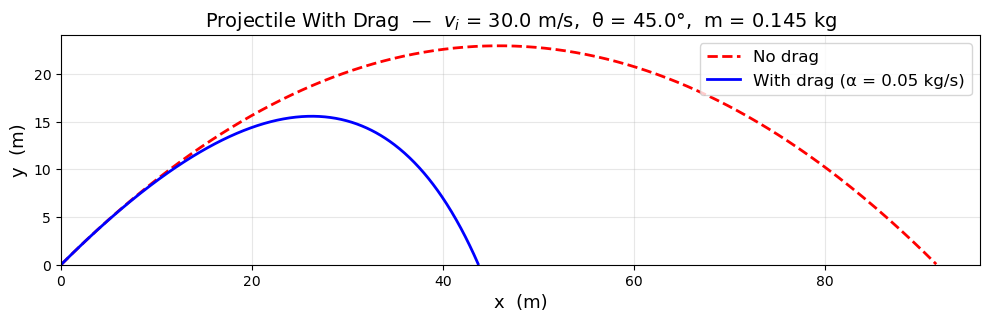

In [50]:
# ---------- Solve with drag ----------
sol_drag = solve_ivp(
    projectile_drag, t_span, s0,
    args=(m, g, alpha),
    events=hit_ground,
    t_eval=t_eval,
    dense_output=True,
    max_step=0.01
)

x_drag, y_drag = sol_drag.y[0], sol_drag.y[1]
vx_drag, vy_drag = sol_drag.y[2], sol_drag.y[3]
t_drag = sol_drag.t

print(f"With drag    →  Range = {x_drag[-1]:.2f} m,  Flight time = {t_drag[-1]:.2f} s")

# ---------- Plot: drag vs no-drag overlay ----------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_nd, y_nd, 'r--', linewidth=2, label='No drag')
ax.plot(x_drag, y_drag, 'b-', linewidth=2, label=f'With drag (α = {alpha} kg/s)')

ax.set_xlabel('x  (m)', fontsize=13)
ax.set_ylabel('y  (m)', fontsize=13)
ax.set_title(f'Projectile With Drag  —  $v_i$ = {vi} m/s,  θ = {theta_deg}°,  m = {m} kg', fontsize=14)
ax.legend(fontsize=12)
ax.set_ylim(bottom=0)
ax.set_xlim(left=0)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Velocity Components vs Time

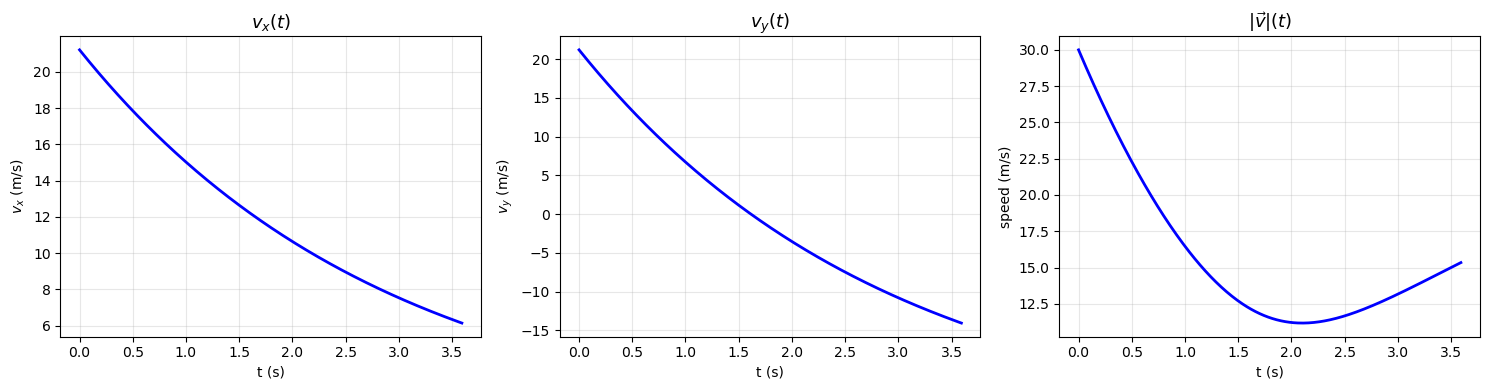

In [51]:
speed_drag = np.sqrt(vx_drag**2 + vy_drag**2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t_drag, vx_drag, 'b-', linewidth=2)
axes[0].set_title('$v_x(t)$', fontsize=13)
axes[0].set_xlabel('t (s)')
axes[0].set_ylabel('$v_x$ (m/s)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_drag, vy_drag, 'b-', linewidth=2)
axes[1].set_title('$v_y(t)$', fontsize=13)
axes[1].set_xlabel('t (s)')
axes[1].set_ylabel('$v_y$ (m/s)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_drag, speed_drag, 'b-', linewidth=2)
axes[2].set_title('$|\\vec{v}|(t)$', fontsize=13)
axes[2].set_xlabel('t (s)')
axes[2].set_ylabel('speed (m/s)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analytical Solution (for validation)

With linear drag $\vec{F}_d = -\alpha\vec{v}$, the equations decouple and have closed-form solutions. Defining $\beta = \alpha / m$:

$$v_x(t) = v_{x0}\,e^{-\beta t}$$

$$v_y(t) = \left(v_{y0} + \frac{g}{\beta}\right)e^{-\beta t} - \frac{g}{\beta}$$

$$x(t) = \frac{v_{x0}}{\beta}\left(1 - e^{-\beta t}\right)$$

$$y(t) = \frac{1}{\beta}\left(v_{y0} + \frac{g}{\beta}\right)\left(1 - e^{-\beta t}\right) - \frac{g}{\beta}\,t$$

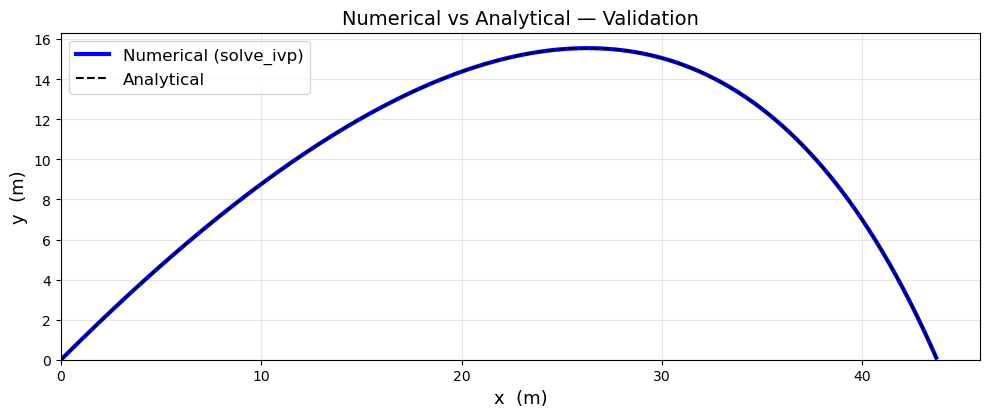

Max |Δx| = 3.55e-14 m
Max |Δy| = 3.02e-14 m


In [52]:
beta = alpha / m

x_ana = (vx0 / beta) * (1 - np.exp(-beta * t_drag))
y_ana = (1 / beta) * (vy0 + g / beta) * (1 - np.exp(-beta * t_drag)) - (g / beta) * t_drag

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_drag, y_drag, 'b-', linewidth=3, label='Numerical (solve_ivp)')
ax.plot(x_ana, y_ana, 'k--', linewidth=1.5, label='Analytical')
ax.set_xlabel('x  (m)', fontsize=13)
ax.set_ylabel('y  (m)', fontsize=13)
ax.set_title('Numerical vs Analytical — Validation', fontsize=14)
ax.legend(fontsize=12)
ax.set_ylim(bottom=0)
ax.set_xlim(left=0)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Max absolute error
err_x = np.max(np.abs(x_drag - x_ana))
err_y = np.max(np.abs(y_drag - y_ana))
print(f"Max |Δx| = {err_x:.2e} m")
print(f"Max |Δy| = {err_y:.2e} m")

## Explore: Vary the Drag Coefficient

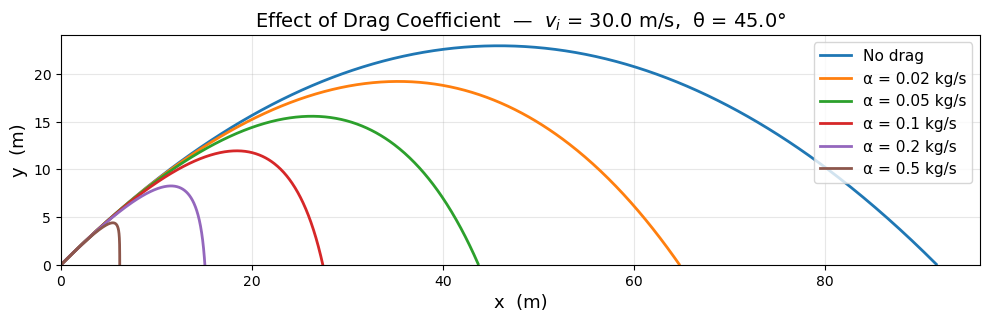

In [53]:
alphas = [0, 0.02, 0.05, 0.1, 0.2, 0.5]

fig, ax = plt.subplots(figsize=(10, 5))

for a in alphas:
    sol = solve_ivp(
        projectile_drag, t_span, s0,
        args=(m, g, a),
        events=hit_ground,
        t_eval=t_eval,
        dense_output=True,
        max_step=0.01
    )
    label = f'α = {a} kg/s' if a > 0 else 'No drag'
    ax.plot(sol.y[0], sol.y[1], linewidth=2, label=label)

ax.set_xlabel('x  (m)', fontsize=13)
ax.set_ylabel('y  (m)', fontsize=13)
ax.set_title(f'Effect of Drag Coefficient  —  $v_i$ = {vi} m/s,  θ = {theta_deg}°', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(bottom=0)
ax.set_xlim(left=0)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Explore: Vary the Launch Angle

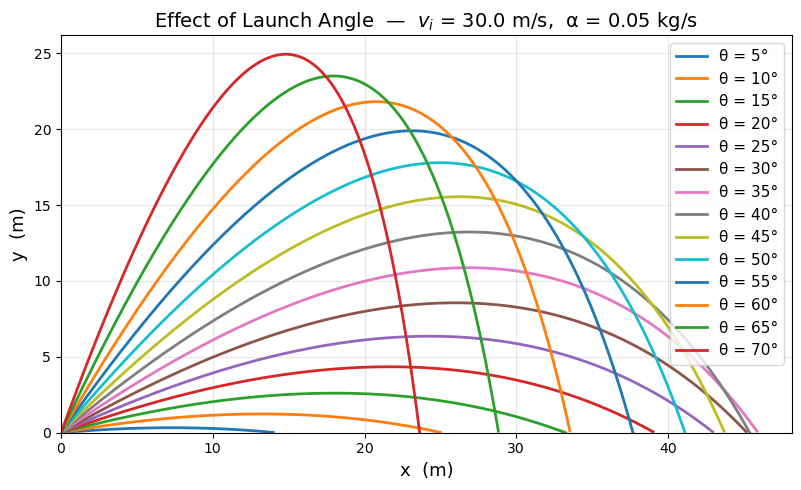

In [55]:
fig, ax = plt.subplots(figsize=(10, 5))

for ang in range(5, 75, 5):
    ang_rad = np.radians(ang)
    s0_ang = [0, 0, vi * np.cos(ang_rad), vi * np.sin(ang_rad)]
    sol = solve_ivp(
        projectile_drag, t_span, s0_ang,
        args=(m, g, alpha),
        events=hit_ground,
        t_eval=t_eval,
        dense_output=True,
        max_step=0.01
    )
    ax.plot(sol.y[0], sol.y[1], linewidth=2, label=f'θ = {ang}°')

ax.set_xlabel('x  (m)', fontsize=13)
ax.set_ylabel('y  (m)', fontsize=13)
ax.set_title(f'Effect of Launch Angle  —  $v_i$ = {vi} m/s,  α = {alpha} kg/s', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(bottom=0)
ax.set_xlim(left=0)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

#### JC: Now we know that the best angles would be from 30 deg to 40 deg lets fine tune the angle with a wider range

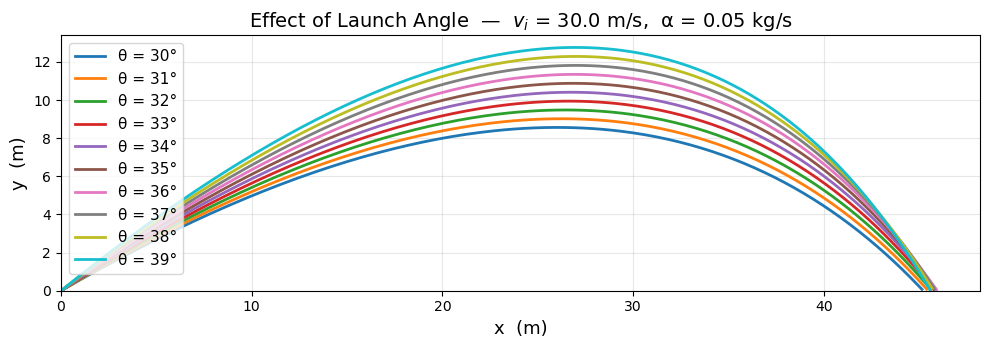

In [56]:
fig, ax = plt.subplots(figsize=(10, 5))

for ang in range(30, 40, 1):
    ang_rad = np.radians(ang)
    s0_ang = [0, 0, vi * np.cos(ang_rad), vi * np.sin(ang_rad)]
    sol = solve_ivp(
        projectile_drag, t_span, s0_ang,
        args=(m, g, alpha),
        events=hit_ground,
        t_eval=t_eval,
        dense_output=True,
        max_step=0.01
    )
    ax.plot(sol.y[0], sol.y[1], linewidth=2, label=f'θ = {ang}°')

ax.set_xlabel('x  (m)', fontsize=13)
ax.set_ylabel('y  (m)', fontsize=13)
ax.set_title(f'Effect of Launch Angle  —  $v_i$ = {vi} m/s,  α = {alpha} kg/s', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(bottom=0)
ax.set_xlim(left=0)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


#### JC: I cant see shit so im just gonna display it as numbers

In [68]:
# Calculate range for each angle
angles = np.linspace(30, 40, 1001)  # 0.1° spacing exactly
ranges = []

print("Launch Angle Analysis (with drag):")
print("="*40)

for ang in angles:
    ang_rad = np.radians(ang)
    s0_ang = [0, 0, vi * np.cos(ang_rad), vi * np.sin(ang_rad)]
    sol = solve_ivp(
        projectile_drag, t_span, s0_ang,
        args=(m, g, alpha),
        events=hit_ground,
        t_eval=t_eval,
        dense_output=True,
        max_step=0.01
    )
    range_val = sol.y[0][-1]  # x value at impact
    ranges.append(range_val)
    print(f"θ = {ang:5.2f}°  →  Range = {range_val:.2f} m")

print("\nDelta X Analysis:")
print("="*40)
max_range_idx = np.argmax(ranges)
max_range = ranges[max_range_idx]
optimal_angle = angles[max_range_idx]

print(f"Maximum range: {max_range:.2f} m at θ = {optimal_angle}°")
print()

for i, (ang, r) in enumerate(zip(angles, ranges)):
    delta_x = r - max_range
    if i == max_range_idx:
        print(f"θ = {ang:5.2f}°  →  Δx = {delta_x:+6.2f} m  ←← OPTIMAL")
    else:
        print(f"θ = {ang:5.2f}°  →  Δx = {delta_x:+6.2f} m")
        
print(f"\nRange spread: {max(ranges) - min(ranges):.2f} m")

Launch Angle Analysis (with drag):
θ = 30.00°  →  Range = 45.14 m
θ = 30.01°  →  Range = 45.14 m
θ = 30.02°  →  Range = 45.14 m
θ = 30.03°  →  Range = 45.13 m
θ = 30.04°  →  Range = 45.13 m
θ = 30.05°  →  Range = 45.12 m
θ = 30.06°  →  Range = 45.22 m
θ = 30.07°  →  Range = 45.22 m
θ = 30.08°  →  Range = 45.21 m
θ = 30.09°  →  Range = 45.21 m
θ = 30.10°  →  Range = 45.20 m
θ = 30.11°  →  Range = 45.20 m
θ = 30.12°  →  Range = 45.19 m
θ = 30.13°  →  Range = 45.19 m
θ = 30.14°  →  Range = 45.19 m
θ = 30.15°  →  Range = 45.18 m
θ = 30.16°  →  Range = 45.18 m
θ = 30.17°  →  Range = 45.17 m
θ = 30.18°  →  Range = 45.17 m
θ = 30.19°  →  Range = 45.16 m
θ = 30.20°  →  Range = 45.26 m
θ = 30.21°  →  Range = 45.26 m
θ = 30.22°  →  Range = 45.25 m
θ = 30.23°  →  Range = 45.25 m
θ = 30.24°  →  Range = 45.24 m
θ = 30.25°  →  Range = 45.24 m
θ = 30.26°  →  Range = 45.23 m
θ = 30.27°  →  Range = 45.23 m
θ = 30.28°  →  Range = 45.22 m
θ = 30.29°  →  Range = 45.22 m
θ = 30.30°  →  Range = 45.21 m
θ = 

#### MORE REFINEMENT

In [70]:
# Calculate range for each angle
angles = np.linspace(35, 36, 1001)  # 0.1° spacing exactly
ranges = []

print("Launch Angle Analysis (with drag):")
print("="*40)

for ang in angles:
    ang_rad = np.radians(ang)
    s0_ang = [0, 0, vi * np.cos(ang_rad), vi * np.sin(ang_rad)]
    sol = solve_ivp(
        projectile_drag, t_span, s0_ang,
        args=(m, g, alpha),
        events=hit_ground,
        t_eval=t_eval,
        dense_output=True,
        max_step=0.01
    )
    range_val = sol.y[0][-1]  # x value at impact
    ranges.append(range_val)
    print(f"θ = {ang:5.4f}°  →  Range = {range_val:.2f} m")

print("\nDelta X Analysis:")
print("="*40)
max_range_idx = np.argmax(ranges)
max_range = ranges[max_range_idx]
optimal_angle = angles[max_range_idx]

print(f"Maximum range: {max_range:.2f} m at θ = {optimal_angle}°")
print()

for i, (ang, r) in enumerate(zip(angles, ranges)):
    delta_x = r - max_range
    if i == max_range_idx:
        print(f"θ = {ang:5.4f}°  →  Δx = {delta_x:+6.2f} m  ←← OPTIMAL")
    else:
        print(f"θ = {ang:5.4f}°  →  Δx = {delta_x:+6.2f} m")
        
print(f"\nRange spread: {max(ranges) - min(ranges):.2f} m")

Launch Angle Analysis (with drag):
θ = 35.0000°  →  Range = 45.86 m
θ = 35.0010°  →  Range = 45.86 m
θ = 35.0020°  →  Range = 45.86 m
θ = 35.0030°  →  Range = 45.86 m
θ = 35.0040°  →  Range = 45.86 m
θ = 35.0050°  →  Range = 45.86 m
θ = 35.0060°  →  Range = 45.86 m
θ = 35.0070°  →  Range = 45.86 m
θ = 35.0080°  →  Range = 45.86 m
θ = 35.0090°  →  Range = 45.86 m
θ = 35.0100°  →  Range = 45.86 m
θ = 35.0110°  →  Range = 45.86 m
θ = 35.0120°  →  Range = 45.86 m
θ = 35.0130°  →  Range = 45.86 m
θ = 35.0140°  →  Range = 45.86 m
θ = 35.0150°  →  Range = 45.85 m
θ = 35.0160°  →  Range = 45.85 m
θ = 35.0170°  →  Range = 45.85 m
θ = 35.0180°  →  Range = 45.85 m
θ = 35.0190°  →  Range = 45.85 m
θ = 35.0200°  →  Range = 45.85 m
θ = 35.0210°  →  Range = 45.85 m
θ = 35.0220°  →  Range = 45.85 m
θ = 35.0230°  →  Range = 45.85 m
θ = 35.0240°  →  Range = 45.85 m
θ = 35.0250°  →  Range = 45.94 m
θ = 35.0260°  →  Range = 45.94 m
θ = 35.0270°  →  Range = 45.94 m
θ = 35.0280°  →  Range = 45.93 m
θ = 35.0